In [ ]:
!pip install pymoo numpy pandas matplotlib


Processing Function: ZDT1 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] ZDT1 — 30 trials completed.
  Summary: IGD Mean = 0.024254 ± 0.006374
           HV Mean  = 5.742670 ± 0.028611


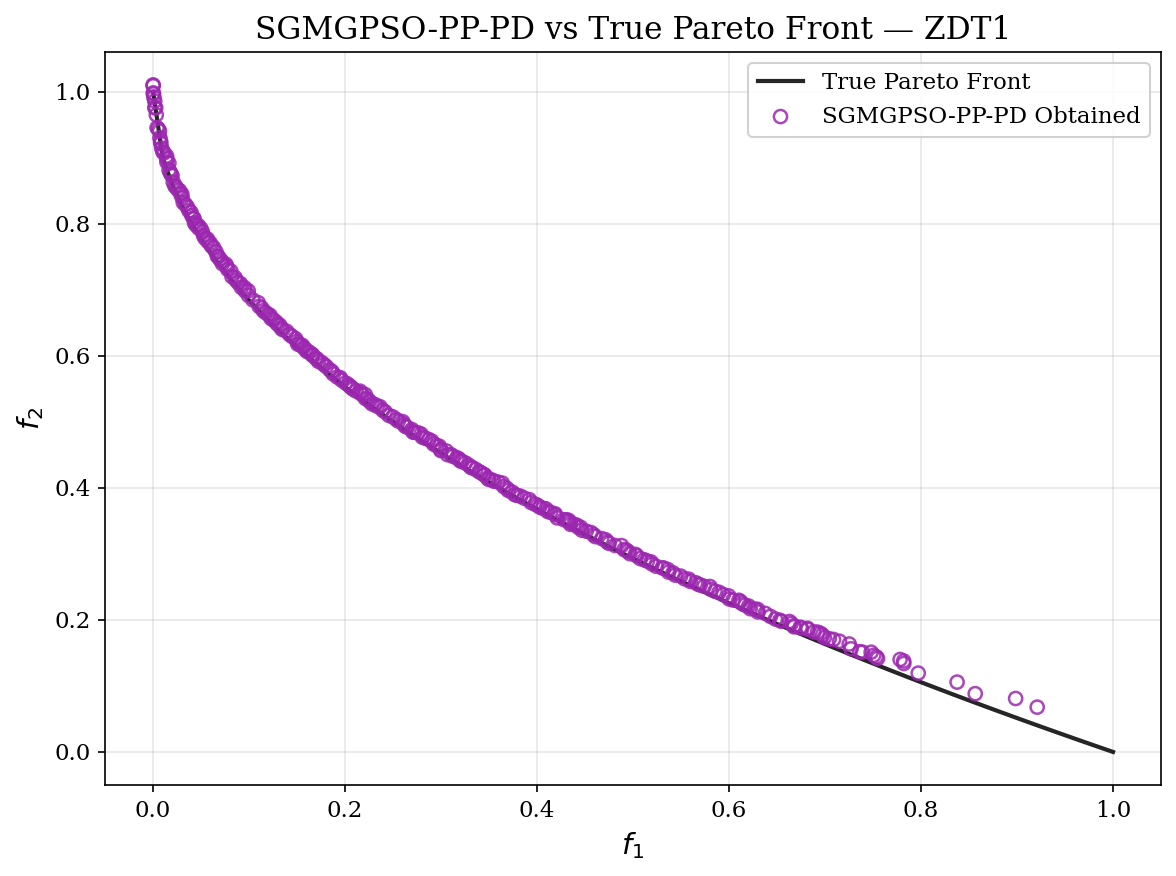


Processing Function: ZDT2 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] ZDT2 — 30 trials completed.
  Summary: IGD Mean = 0.047490 ± 0.028306
           HV Mean  = 5.025217 ± 0.236468


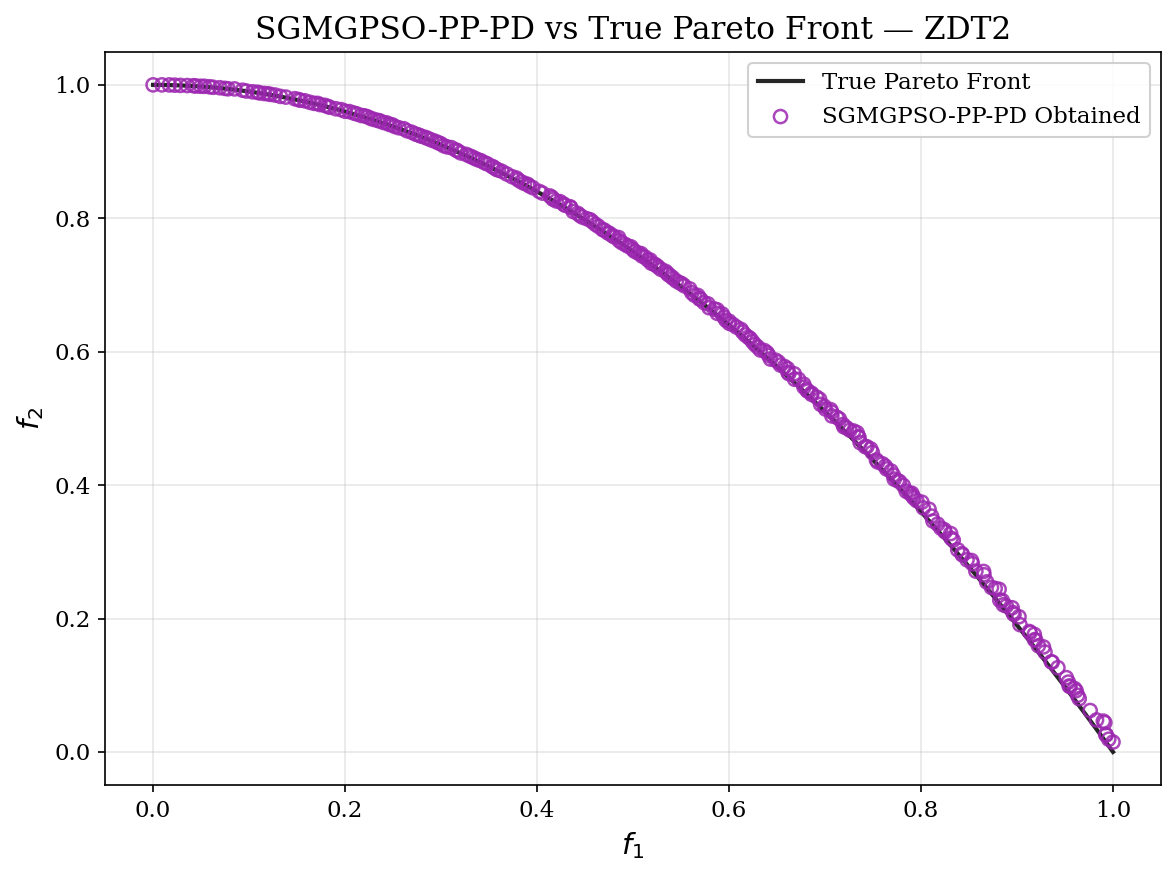


Processing Function: ZDT3 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] ZDT3 — 30 trials completed.
  Summary: IGD Mean = 0.081116 ± 0.021405
           HV Mean  = 6.818929 ± 0.175503


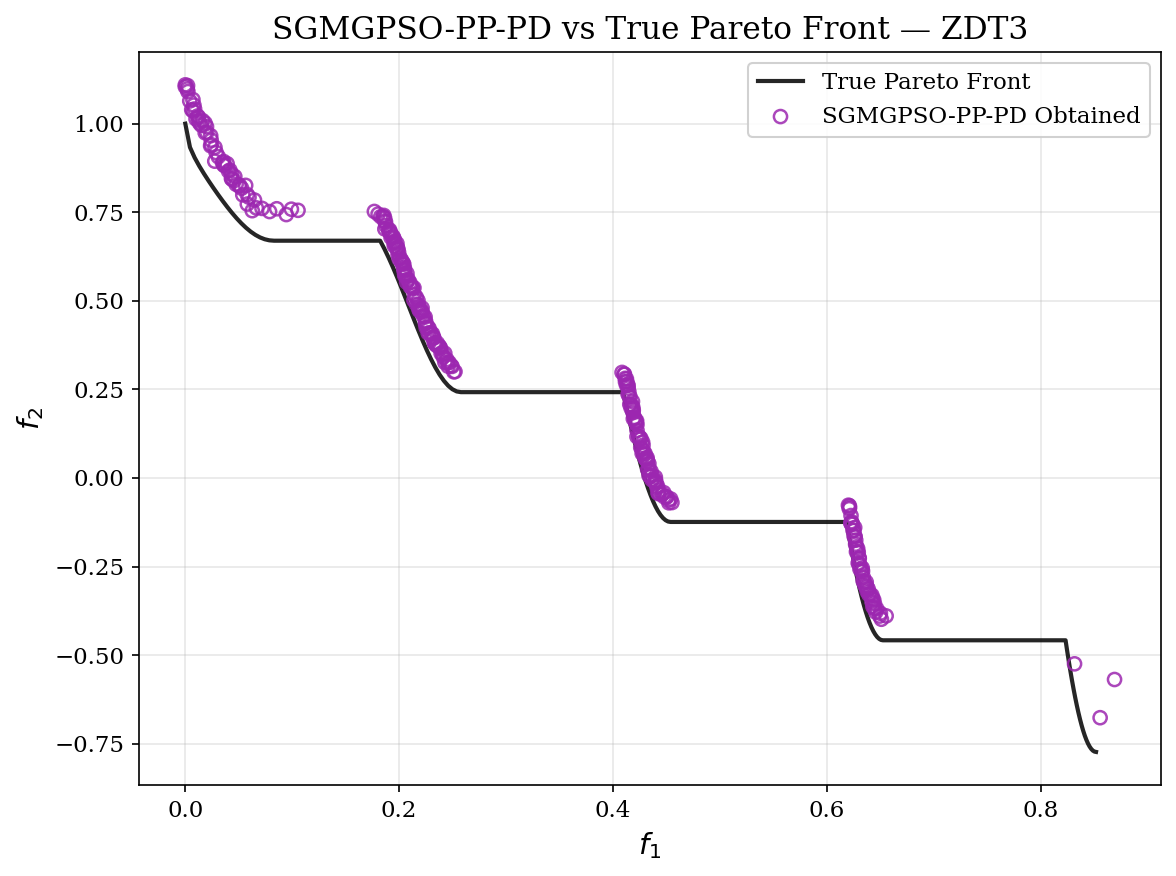


Processing Function: ZDT4 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] ZDT4 — 30 trials completed.
  Summary: IGD Mean = 15.482856 ± 2.839294
           HV Mean  = 0.000000 ± 0.000000


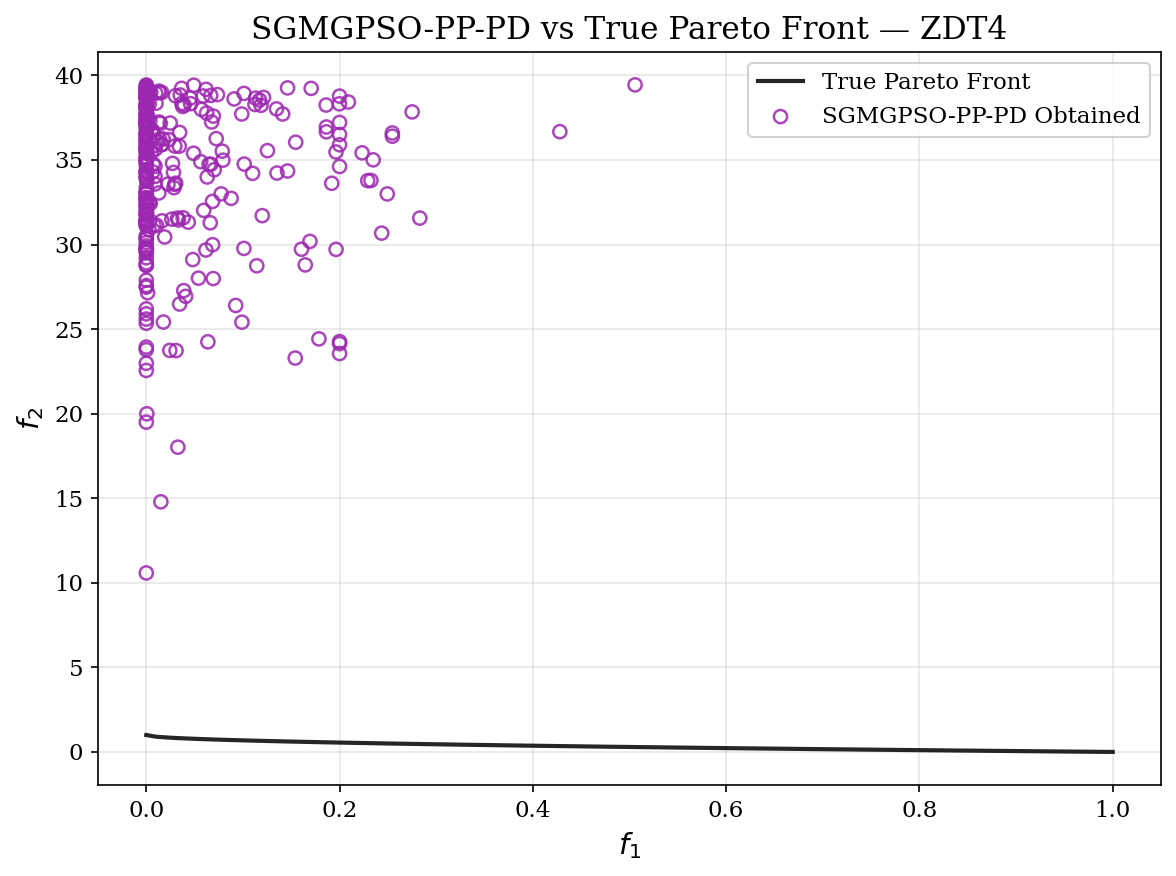


Processing Function: ZDT6 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] ZDT6 — 30 trials completed.
  Summary: IGD Mean = 0.001116 ± 0.000073
           HV Mean  = 5.153501 ± 0.000024


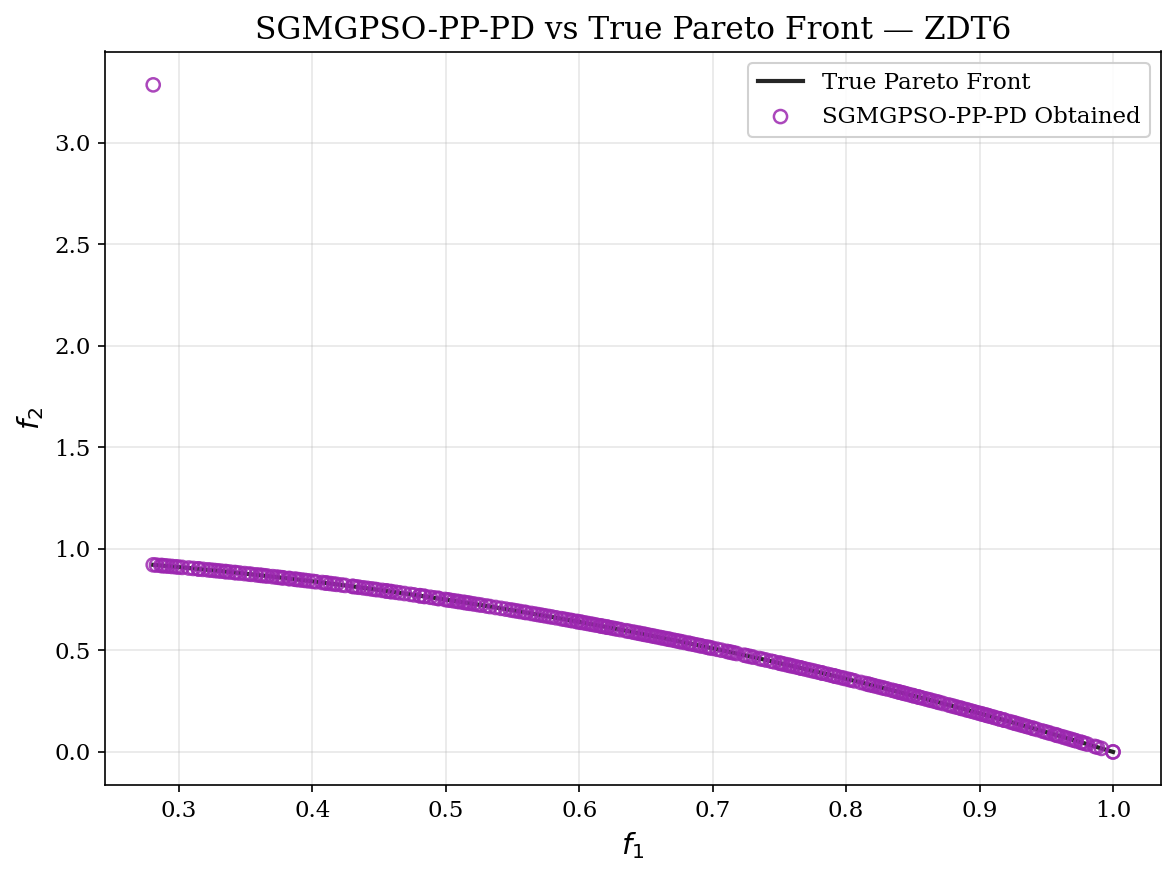


Processing Function: WFG1 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG1 — 30 trials completed.
  Summary: IGD Mean = 1.435778 ± 0.028911
           HV Mean  = 44.753519 ± 0.831884


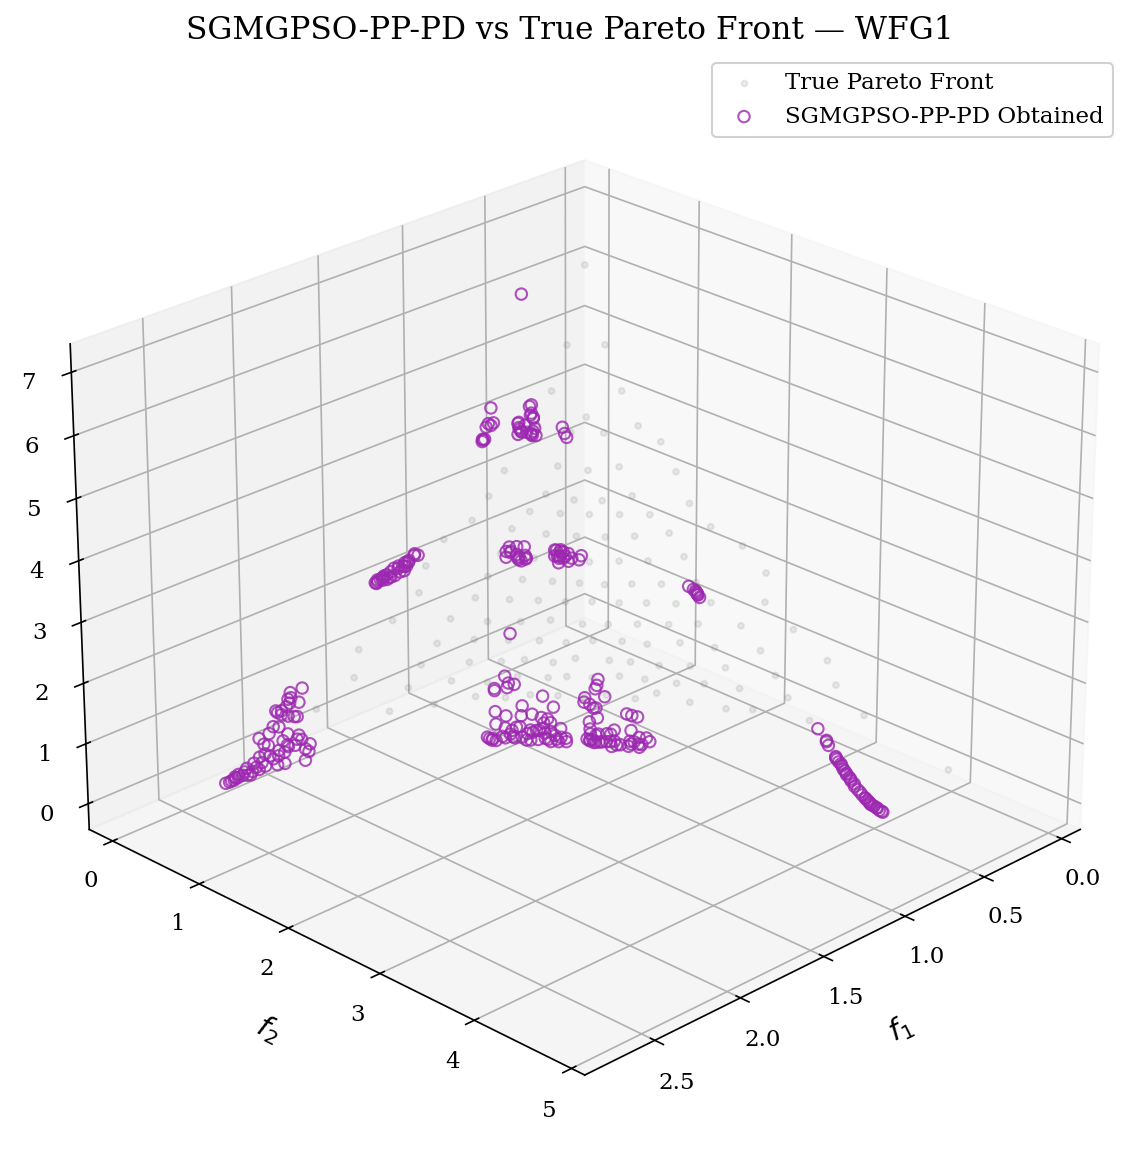


Processing Function: WFG2 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG2 — 30 trials completed.
  Summary: IGD Mean = 0.439088 ± 0.127070
           HV Mean  = 86.182719 ± 6.113908


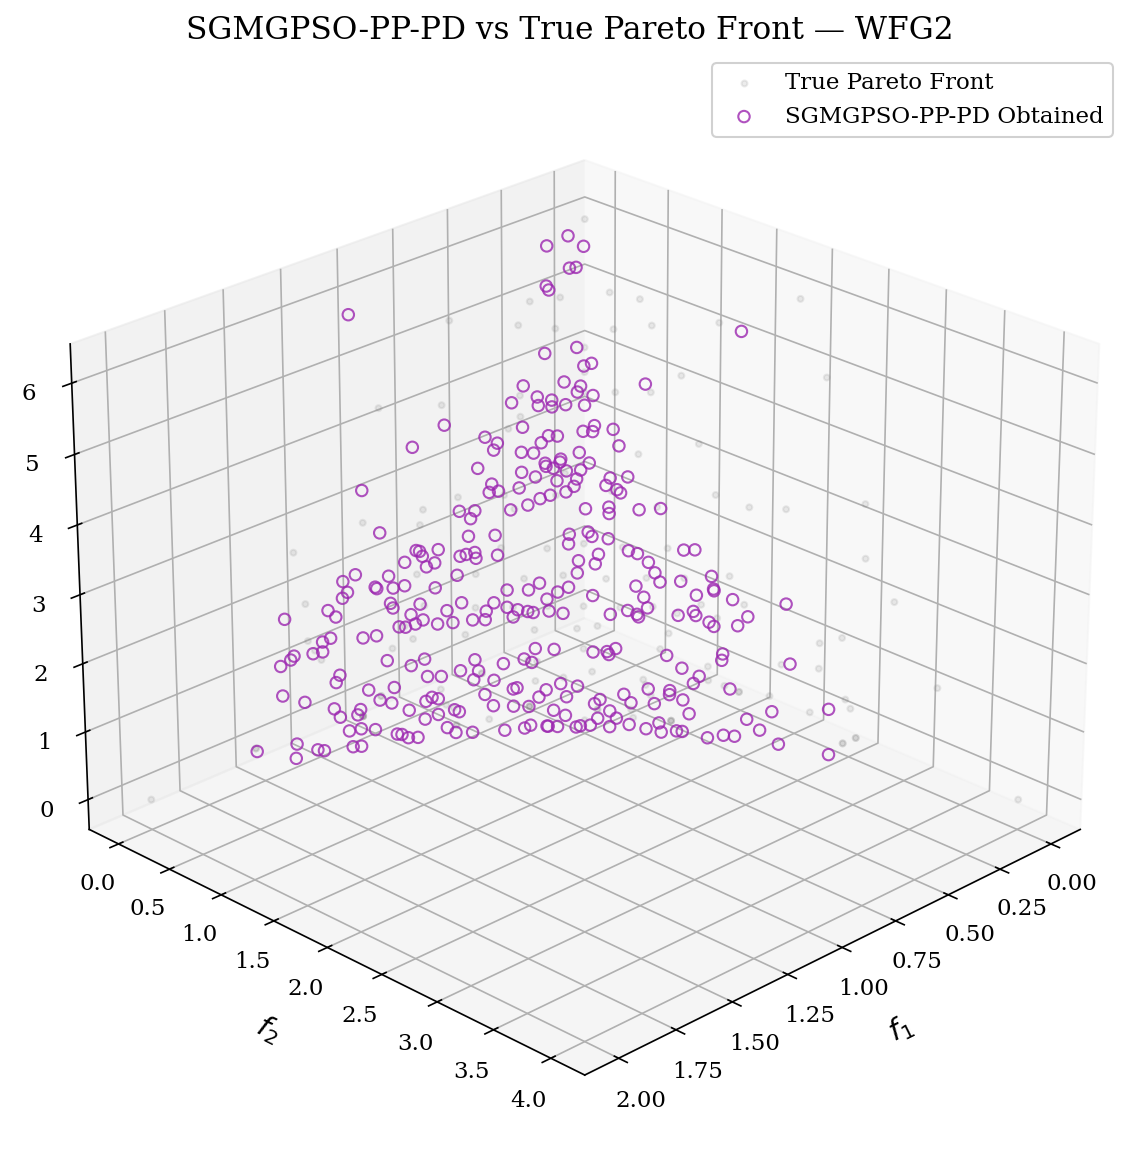


Processing Function: WFG3 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG3 — 30 trials completed.
  Summary: IGD Mean = 0.275285 ± 0.024222
           HV Mean  = 64.058447 ± 0.721650


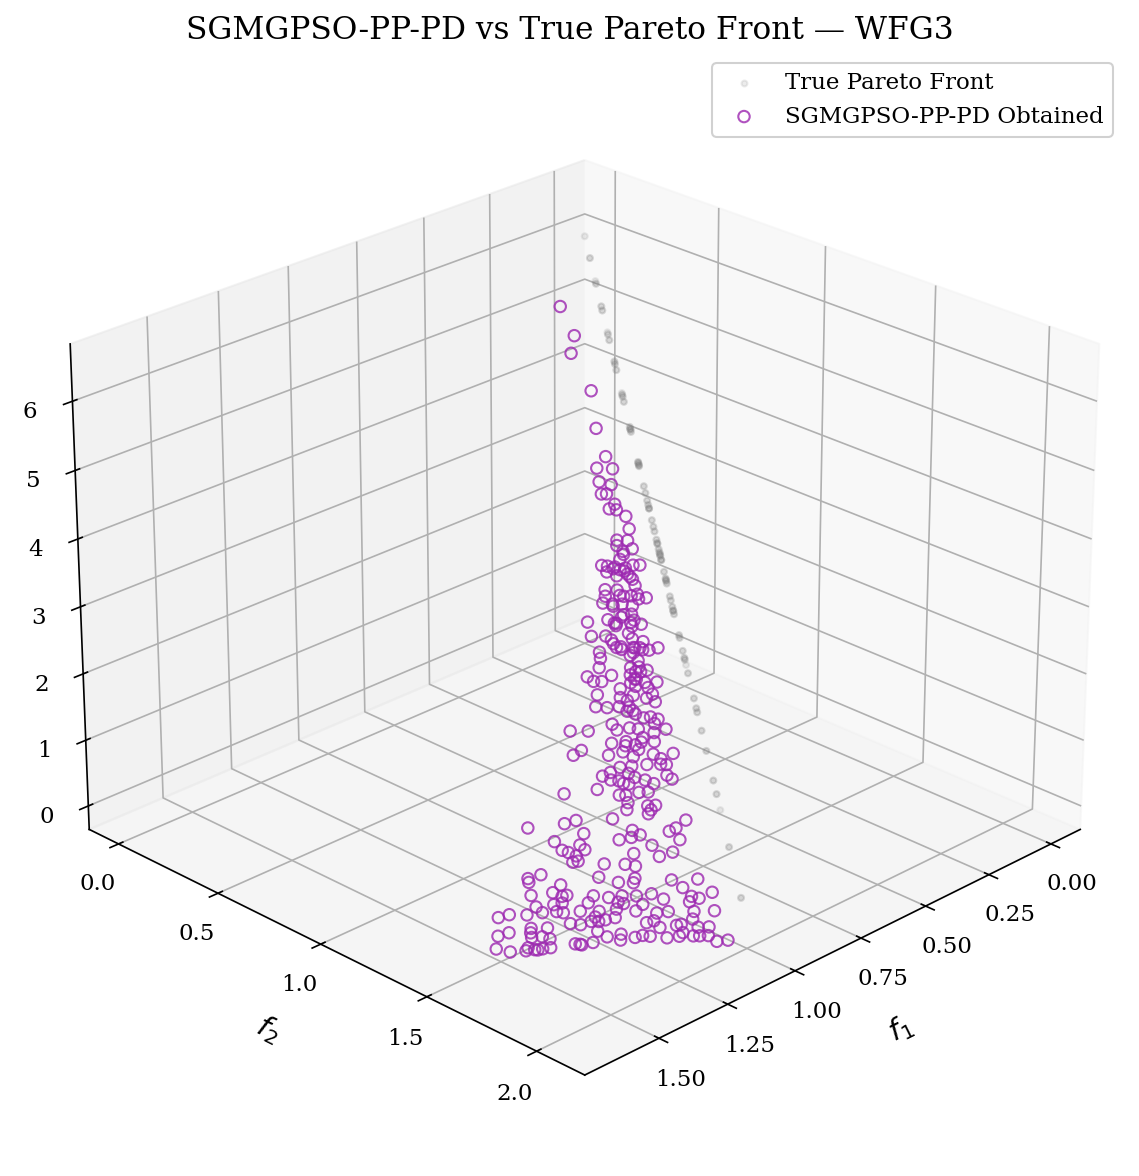


Processing Function: WFG4 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG4 — 30 trials completed.
  Summary: IGD Mean = 0.234788 ± 0.008892
           HV Mean  = 69.112592 ± 0.388847


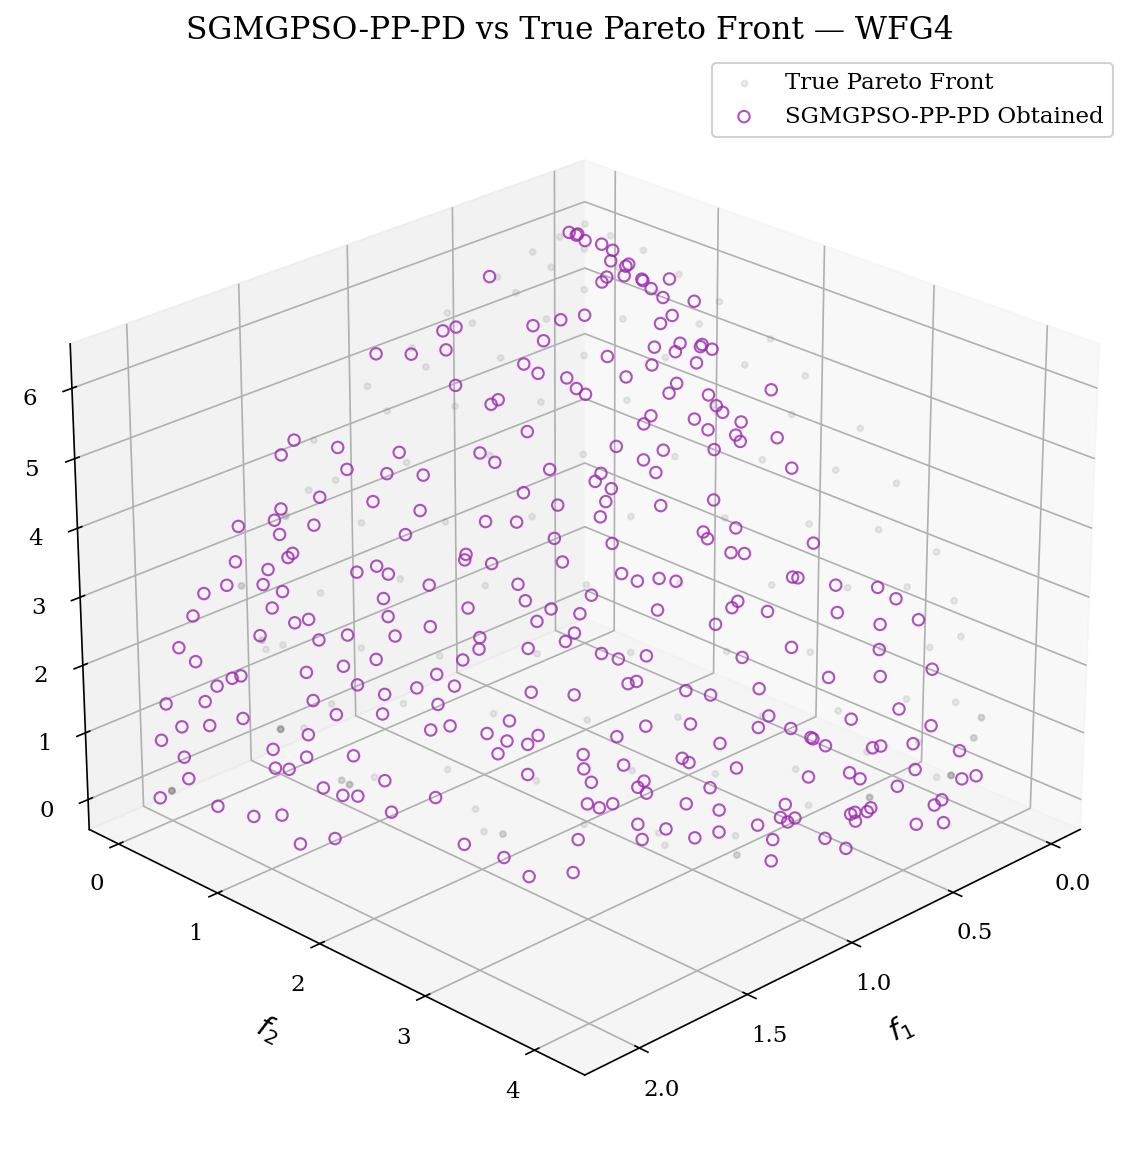


Processing Function: WFG5 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG5 — 30 trials completed.
  Summary: IGD Mean = 0.870227 ± 0.030388
           HV Mean  = 40.213502 ± 0.991870


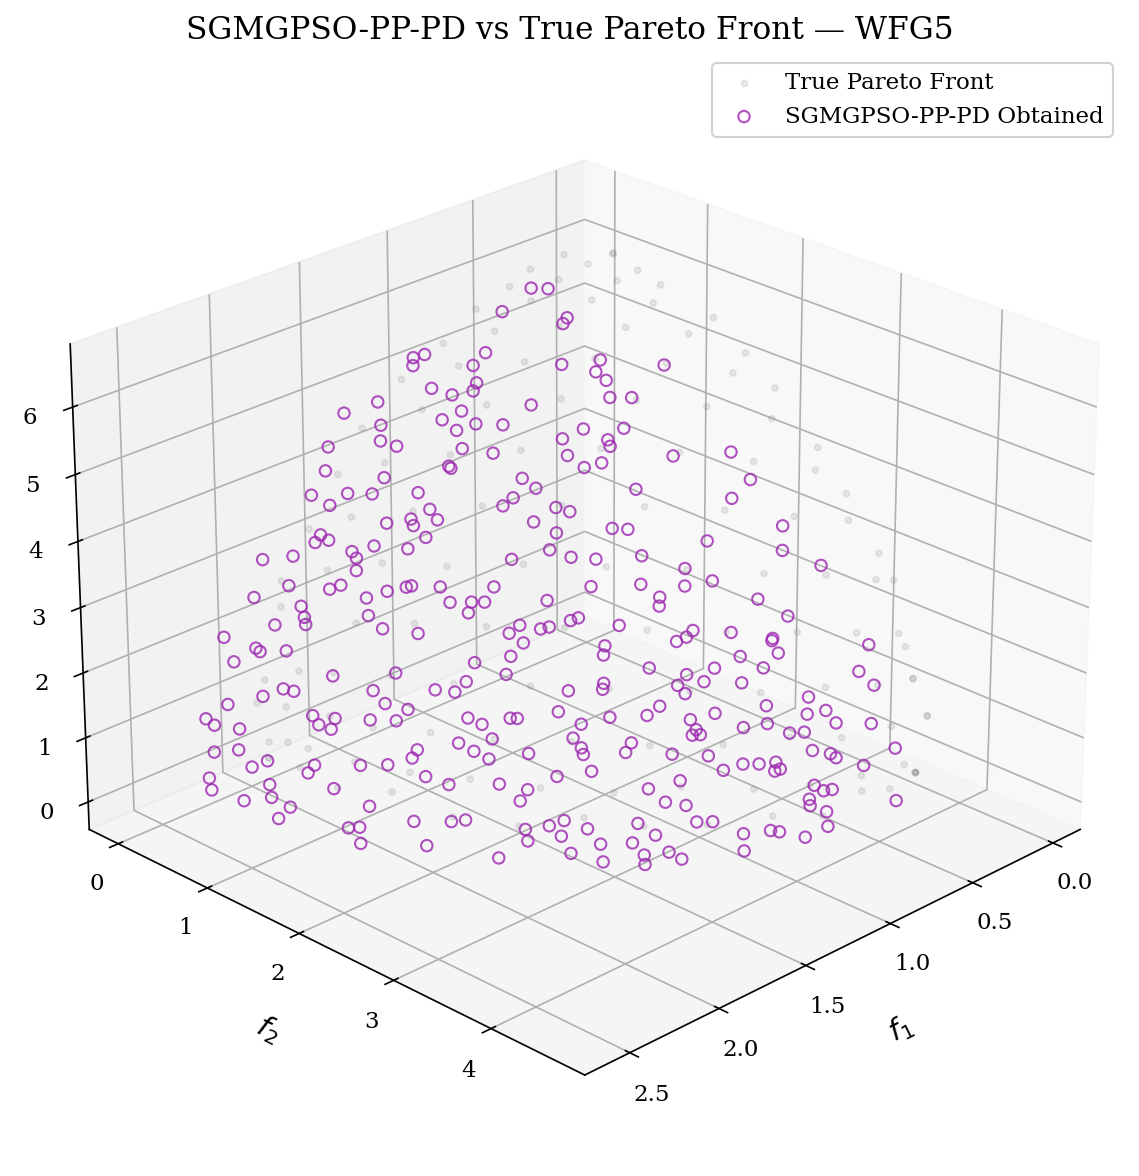


Processing Function: WFG6 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG6 — 30 trials completed.
  Summary: IGD Mean = 0.370591 ± 0.016073
           HV Mean  = 61.691080 ± 0.762896


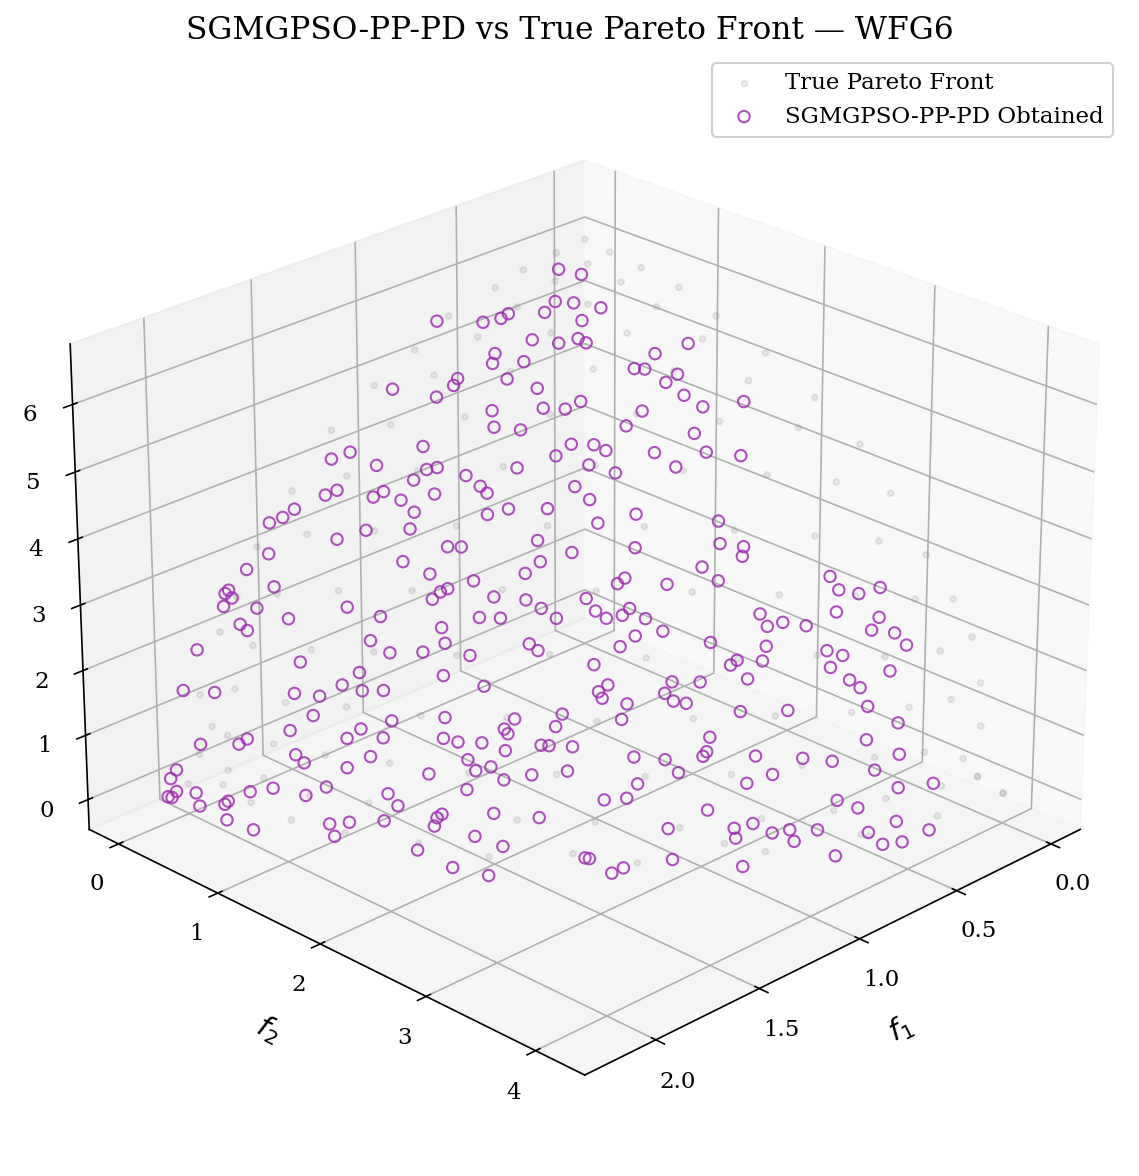


Processing Function: WFG7 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG7 — 30 trials completed.
  Summary: IGD Mean = 0.394947 ± 0.005167
           HV Mean  = 62.118560 ± 0.275388


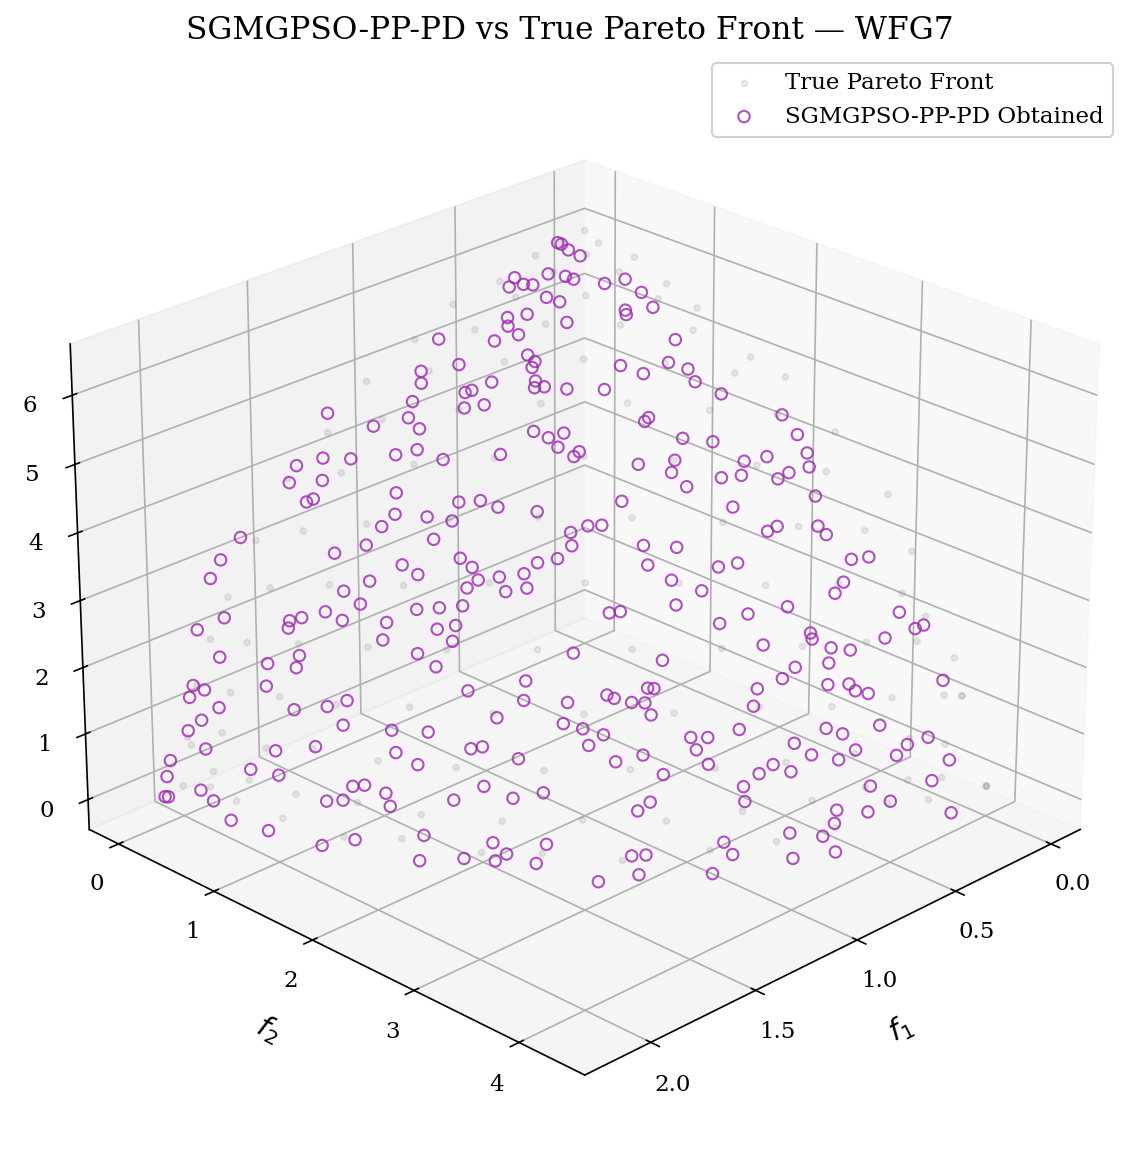


Processing Function: WFG8 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG8 — 30 trials completed.
  Summary: IGD Mean = 0.534131 ± 0.024507
           HV Mean  = 53.909877 ± 1.500518


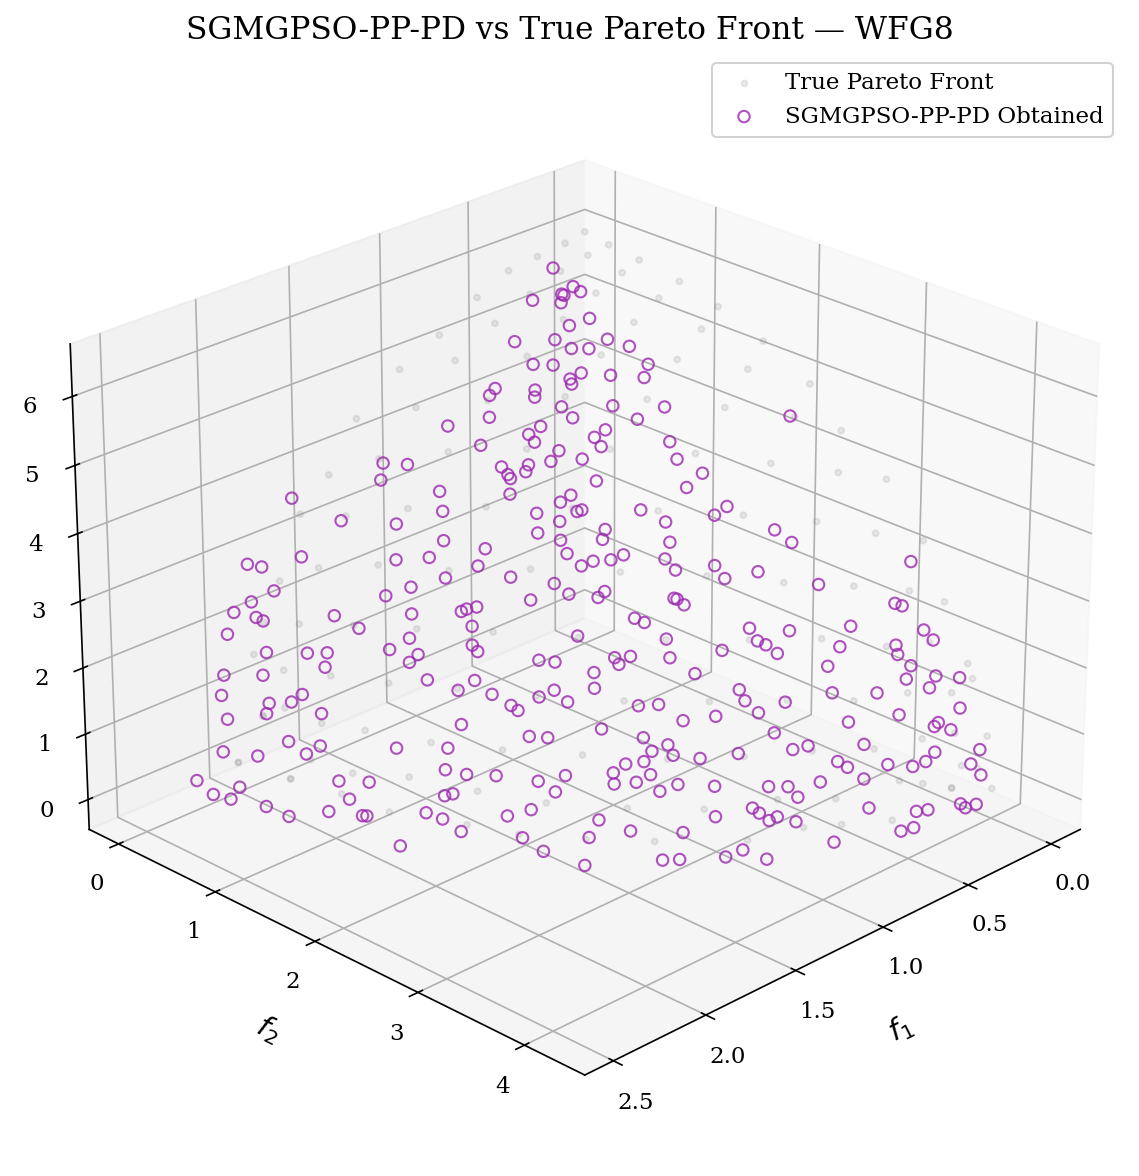


Processing Function: WFG9 (SGMGPSO-PP-PD)
  Trial 30/30 running...
  [Done] WFG9 — 30 trials completed.
  Summary: IGD Mean = 0.261311 ± 0.007633
           HV Mean  = 66.945930 ± 0.533517


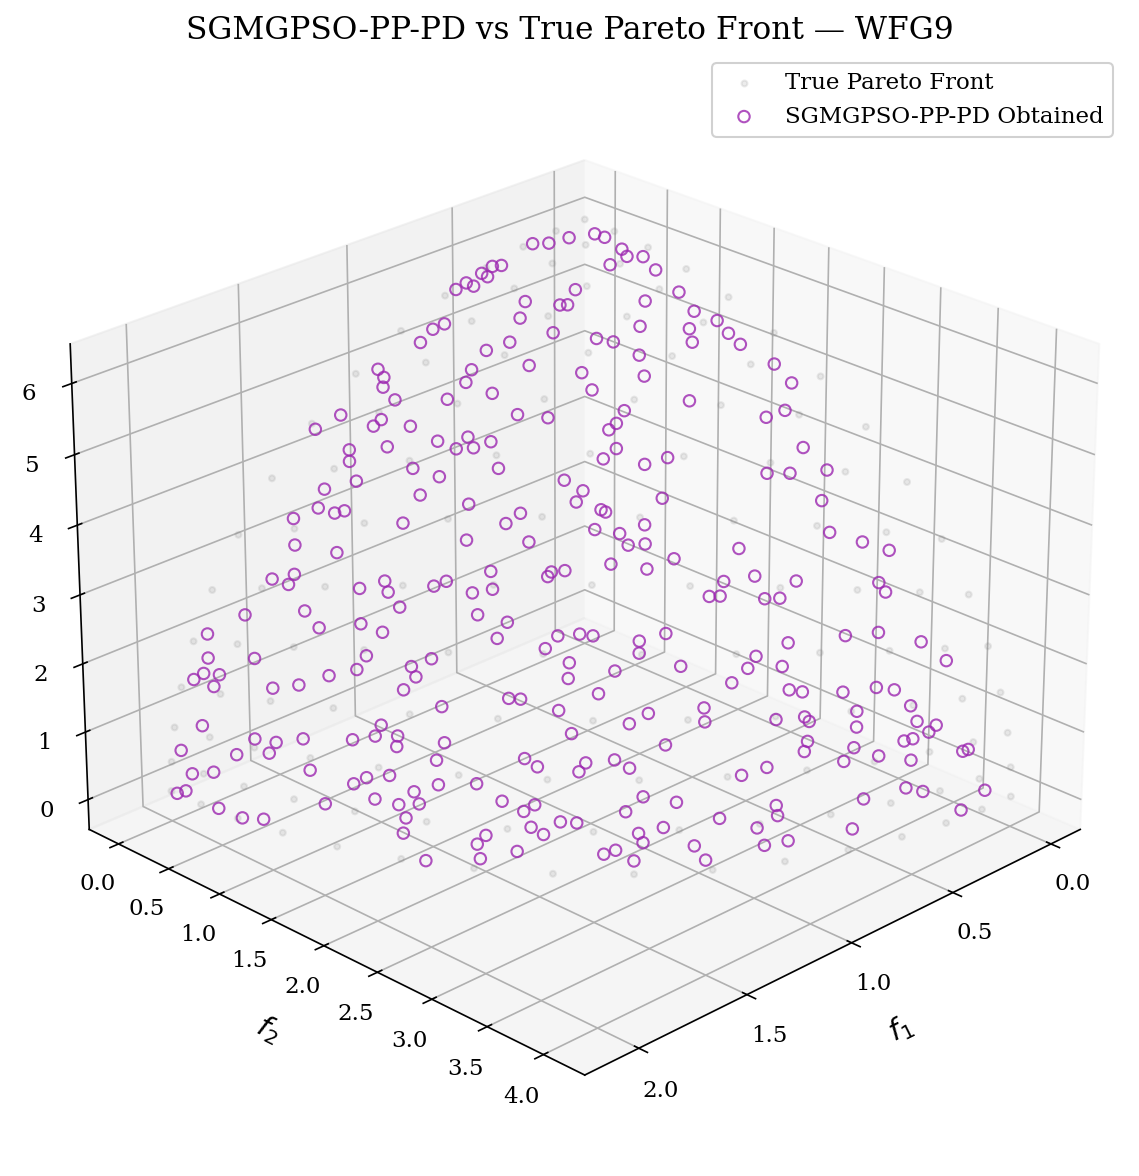


FINAL SUMMARY TABLE — SGMGPSO-PP-PD
Function  IGD_Mean  IGD_Std   HV_Mean   HV_Std
    ZDT1  0.024254 0.006374  5.742670 0.028611
    ZDT2  0.047490 0.028306  5.025217 0.236468
    ZDT3  0.081116 0.021405  6.818929 0.175503
    ZDT4 15.482856 2.839294  0.000000 0.000000
    ZDT6  0.001116 0.000073  5.153501 0.000024
    WFG1  1.435778 0.028911 44.753519 0.831884
    WFG2  0.439088 0.127070 86.182719 6.113908
    WFG3  0.275285 0.024222 64.058447 0.721650
    WFG4  0.234788 0.008892 69.112592 0.388847
    WFG5  0.870227 0.030388 40.213502 0.991870
    WFG6  0.370591 0.016073 61.691080 0.762896
    WFG7  0.394947 0.005167 62.118560 0.275388
    WFG8  0.534131 0.024507 53.909877 1.500518
    WFG9  0.261311 0.007633 66.945930 0.533517


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pymoo.core.population import Population
from pymoo.problems import get_problem
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.algorithms.moo.nsga2 import RankAndCrowdingSurvival

# ============================================================
# MODEL 4: SGMGPSO-PP-PD (Per-Particle Per-Dimension Stability)
# Unique stability params for EACH particle i and EACH dimension d
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3
})

ALGO_NAME = "SGMGPSO-PP-PD"
N_PARTICLES = 150
ARCHIVE_SIZE = 300
N_RUNS = 30

# --- Reusable Functions ---

def polynomial_mutation(X, xl, xu, eta=20):
    """Polynomial mutation for maintaining search diversity."""
    n, d = X.shape
    prob = 1.0 / d
    mut_mask = np.random.random((n, d)) < prob
    delta = xu - xl
    delta = np.where(delta < 1e-10, 1e-10, delta)
    u = np.random.random((n, d))
    delta1 = np.clip((X - xl) / delta, 0, 1)
    delta2 = np.clip((xu - X) / delta, 0, 1)
    pow_val = 1.0 / (eta + 1.0)
    mask_low = u <= 0.5
    xy = 1.0 - delta1
    val = 2.0 * u + (1.0 - 2.0 * u) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_low = np.power(np.clip(val, 0, None), pow_val) - 1.0
    xy = 1.0 - delta2
    val = 2.0 * (1.0 - u) + 2.0 * (u - 0.5) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_high = 1.0 - np.power(np.clip(val, 0, None), pow_val)
    deltaq = np.where(mask_low, deltaq_low, deltaq_high)
    X_mutated = X + deltaq * delta * mut_mask
    return np.clip(X_mutated, xl, xu)

def sample_mgpso_stability_matrix(n_particles, n_dims):
    """
    Samples unique stability parameters for EACH particle i and EACH dimension d.
    Vectorized implementation with improved rejection sampling bounds.
    """
    W = np.zeros((n_particles, n_dims))
    L = np.zeros((n_particles, n_dims))
    C1 = np.zeros((n_particles, n_dims))
    C2 = np.zeros((n_particles, n_dims))
    C3 = np.zeros((n_particles, n_dims))

    total = n_particles * n_dims
    # Vectorized batch sampling for efficiency
    filled = np.zeros((n_particles, n_dims), dtype=bool)
    
    for attempt in range(30):
        remaining = ~filled
        n_remaining = remaining.sum()
        if n_remaining == 0:
            break
        
        w = np.random.uniform(0.1, 0.8, n_remaining)
        lambd = np.random.uniform(0.2, 0.8, n_remaining)
        c1 = np.random.uniform(0.5, 2.0, n_remaining)
        c2 = np.random.uniform(0.5, 2.0, n_remaining)
        c3 = np.random.uniform(0.5, 3.0, n_remaining)
        
        C = c1 + lambd * c2 + (1 - lambd) * c3
        C_var = (c1**2 + (lambd**2)*(c2**2) + ((1-lambd)**2)*(c3**2))
        num = 4 * (1 - w**2)
        den = (1 - w) + (C_var * (1 + w)) / (3 * (C**2))
        
        valid = (C > 0) & (den > 0) & (C < (num / den))
        
        # Fill in the valid ones
        rows, cols = np.where(remaining)
        valid_indices = np.where(valid[:len(rows)])[0]
        
        for idx in valid_indices:
            r, c_idx = rows[idx], cols[idx]
            if not filled[r, c_idx]:
                W[r, c_idx] = w[idx]
                L[r, c_idx] = lambd[idx]
                C1[r, c_idx] = c1[idx]
                C2[r, c_idx] = c2[idx]
                C3[r, c_idx] = c3[idx]
                filled[r, c_idx] = True
    
    # Fill remaining with default stable values
    unfilled = ~filled
    W[unfilled] = 0.4
    L[unfilled] = 0.5
    C1[unfilled] = 1.2
    C2[unfilled] = 1.2
    C3[unfilled] = 1.8
                
    return W, L, C1, C2, C3

def update_archive(problem, archive, new_pop, max_size=ARCHIVE_SIZE):
    """Updates external archive using pymoo's RankAndCrowding survival."""
    if archive is None or len(archive) == 0:
        combined = new_pop
    else:
        combined = Population.merge(archive, new_pop)
    survival = RankAndCrowdingSurvival()
    return survival.do(problem, combined, n_survive=min(len(combined), max_size))

def tournament_selection_archive(archive, size=5):
    """Tournament selection based on crowding distance."""
    if len(archive) == 0: return None
    indices = np.random.choice(len(archive), min(size, len(archive)), replace=False)
    candidates = archive[indices]
    cds = candidates.get("crowding")
    if cds is not None:
        cds_safe = np.nan_to_num(cds, nan=0.0, posinf=1e6)
        return candidates[np.argmax(cds_safe)].x
    return candidates[np.random.randint(len(candidates))].x

# --- Main SGMGPSO-PP-PD Logic ---

def run_sgmgpso_pp_pd(problem_obj, n_particles=N_PARTICLES, n_gen=300, seed=0):
    np.random.seed(seed)
    xl, xu = problem_obj.bounds()
    n_dims = problem_obj.n_var
    vmax = 0.2 * (xu - xl)  # Velocity clamping
    
    # Initialize
    X = np.random.uniform(xl, xu, (n_particles, n_dims))
    V = np.random.uniform(-0.1 * (xu - xl), 0.1 * (xu - xl), (n_particles, n_dims))
    F = problem_obj.evaluate(X)
    pop = Population.new("X", X, "F", F)
    
    pbest_X, pbest_F = np.copy(X), np.copy(F)
    archive = Population()
    archive = update_archive(problem_obj, archive, pop)
    
    for gen in range(n_gen):
        # Sample parameter matrices: unique values for every (i, d)
        W, L, C1, C2, C3 = sample_mgpso_stability_matrix(n_particles, n_dims)
        
        for i in range(n_particles):
            # Neighborhood Guide (Ring radius 3)
            nb_idx = np.arange(i - 3, i + 4) % n_particles
            lbest_idx = np.argmin(np.sum(pbest_F[nb_idx], axis=1))
            y_hat = pbest_X[nb_idx[lbest_idx]]
            
            # Archive Guide
            a_hat = tournament_selection_archive(archive, size=5)
            if a_hat is None: a_hat = y_hat
            
            # Random vectors
            r1 = np.random.random(n_dims)
            r2 = np.random.random(n_dims)
            r3 = np.random.random(n_dims)
            
            # Per-Dimension Velocity Update using the PP-PD matrices
            V[i] = (W[i] * V[i] + 
                    C1[i] * r1 * (pbest_X[i] - X[i]) + 
                    L[i] * C2[i] * r2 * (y_hat - X[i]) + 
                    (1 - L[i]) * C3[i] * r3 * (a_hat - X[i]))
            
            V[i] = np.clip(V[i], -vmax, vmax)  # Velocity clamping
            X[i] = np.clip(X[i] + V[i], xl, xu)
            
        # Apply mutation
        X = polynomial_mutation(X, xl, xu, eta=20)
        
        F = problem_obj.evaluate(X)
        pop = Population.new("X", X, "F", F)
        
        for i in range(n_particles):
            if np.all(F[i] <= pbest_F[i]) and np.any(F[i] < pbest_F[i]):
                pbest_X[i], pbest_F[i] = np.copy(X[i]), np.copy(F[i])
            elif not (np.all(pbest_F[i] <= F[i]) and np.any(pbest_F[i] < F[i])):
                if np.random.random() < 0.5:
                    pbest_X[i], pbest_F[i] = np.copy(X[i]), np.copy(F[i])
                
        archive = update_archive(problem_obj, archive, pop)

    return archive

# --- Publication-Quality Plotting ---

def plot_pareto_comparison_2d(pf, obtained_F, algo_name, func_name, output_path, color='#9C27B0'):
    fig, ax = plt.subplots(figsize=(8, 6))
    if pf is not None:
        sorted_pf = pf[pf[:, 0].argsort()]
        ax.plot(sorted_pf[:, 0], sorted_pf[:, 1], color='black', lw=2.0, 
                label='True Pareto Front', alpha=0.85, zorder=5)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], facecolor='none', 
              edgecolor=color, s=40, linewidths=1.2, 
              label=f'{algo_name} Obtained', alpha=0.85, zorder=10)
    ax.set_xlabel(r'$f_1$')
    ax.set_ylabel(r'$f_2$')
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_pareto_comparison_3d(pf, obtained_F, algo_name, func_name, output_path, color='#9C27B0'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    if pf is not None:
        ax.scatter(pf[:, 0], pf[:, 1], pf[:, 2], c='gray', s=8, 
                  label='True Pareto Front', alpha=0.15, zorder=1)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], obtained_F[:, 2], 
             facecolor='none', edgecolor=color, s=30, linewidths=1.0,
             label=f'{algo_name} Obtained', alpha=0.8, zorder=10)
    ax.set_xlabel(r'$f_1$', labelpad=10)
    ax.set_ylabel(r'$f_2$', labelpad=10)
    ax.set_zlabel(r'$f_3$', labelpad=10)
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# --- Experiment Runner ---

def main():
    benchmarks = ["zdt1", "zdt2", "zdt3", "zdt4", "zdt6", 
                  "wfg1", "wfg2", "wfg3", "wfg4", "wfg5", "wfg6", "wfg7", "wfg8", "wfg9"]
    
    all_results = []
    
    for b_name in benchmarks:
        print(f"\n{'='*60}")
        print(f"Processing Function: {b_name.upper()} ({ALGO_NAME})")
        print(f"{'='*60}")
        output_dir = f"./results/SGMGPSO_PP_PD/{b_name}/"
        os.makedirs(output_dir, exist_ok=True)
        
        is_wfg = b_name.lower().startswith("wfg")
        problem = get_problem(b_name, n_var=24, n_obj=3, k=4) if is_wfg else get_problem(b_name)
        
        n_gen = 400 if is_wfg else 300
        if b_name.lower() == 'zdt4':
            n_gen = 500
        
        pf = problem.pareto_front()
        ref_point = np.array([3.0, 5.0, 7.0]) if is_wfg else np.ones(problem.n_obj) * 2.5
        
        run_results = []
        best_igd = np.inf
        best_F = None
        
        for run in range(N_RUNS):
            print(f"  Trial {run + 1}/{N_RUNS} running...", end="\r")
            res_archive = run_sgmgpso_pp_pd(problem, n_gen=n_gen, seed=run)
            F = res_archive.get("F")
            
            if pf is not None:
                igd = IGD(pf).do(F)
                hv = HV(ref_point=ref_point).do(F)
            else:
                igd, hv = np.nan, np.nan
            run_results.append({"run": run + 1, "IGD": igd, "HV": hv})
            
            if igd < best_igd:
                best_igd = igd
                best_F = F.copy()
            
        print(f"\n  [Done] {b_name.upper()} — {N_RUNS} trials completed.")
        df = pd.DataFrame(run_results)
        df.to_csv(f"{output_dir}metrics.csv", index=False)
        
        igd_mean, igd_std = df['IGD'].mean(), df['IGD'].std()
        hv_mean, hv_std = df['HV'].mean(), df['HV'].std()
        
        print(f"  Summary: IGD Mean = {igd_mean:.6f} ± {igd_std:.6f}")
        print(f"           HV Mean  = {hv_mean:.6f} ± {hv_std:.6f}")
        
        all_results.append({
            'Function': b_name.upper(),
            'IGD_Mean': igd_mean, 'IGD_Std': igd_std,
            'HV_Mean': hv_mean, 'HV_Std': hv_std
        })
        
        if problem.n_obj == 2:
            plot_pareto_comparison_2d(pf, best_F, ALGO_NAME, b_name.upper(),
                                     f"{output_dir}pareto_front_comparison.png")
        else:
            plot_pareto_comparison_3d(pf, best_F, ALGO_NAME, b_name.upper(),
                                     f"{output_dir}pareto_front_comparison.png")
    
    print(f"\n{'='*80}")
    print(f"FINAL SUMMARY TABLE — {ALGO_NAME}")
    print(f"{'='*80}")
    summary_df = pd.DataFrame(all_results)
    summary_df.to_csv(f"./results/SGMGPSO_PP_PD/summary.csv", index=False)
    print(summary_df.to_string(index=False))

if __name__ == "__main__":
    main()